# Two-Stage log g Model — Results Viewer

Displays results from the Stage 2 log g model trained by `run_training_logg_twostage.py`.
No training is performed here.

**Pipeline**:
1. Stage 1: Teff ANN (190 features) → predicts log10(Teff)
2. Stage 2: log g ANN (191 features = 190 + predicted log10(Teff)) → predicts log g

**Baselines to beat**:
- Residual ANN, single-output: R² = 0.519, RMSE = 0.199 dex
- Multi-output (homoscedastic): R² = 0.483, RMSE = 0.207 dex

**Expected artifacts**:
- `models/teff_190/stellar_teff_190feat_best.pth`  ← Stage 1
- `models/teff_190/scaler_teff_190.pkl`
- `models/logg_twostage/stellar_logg_twostage_best.pth`  ← Stage 2
- `models/logg_twostage/scaler_logg_twostage.pkl`
- `results/logg_twostage/test_metrics.json`

## 1. Imports & Configuration

In [2]:
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from IPython.display import Image as IPyImage, display as ipy_display

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_context('talk')

DEVICE = torch.device('cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cpu


## 2. Paths

In [4]:
PROJECT_ROOT    = Path('C:/git_repo/cool-dwarf_stellar_parameter_inference_from_survey_data')
DATA_PATH       = PROJECT_ROOT / 'data' / 'logg_final_df' / 'cool_dwarf_catalog_FGKM_consolidated.csv'
STAGE1_MODEL    = PROJECT_ROOT / 'models' / 'teff_190' / 'stellar_teff_190feat_best.pth'
STAGE1_SCALER   = PROJECT_ROOT / 'models' / 'teff_190' / 'scaler_teff_190.pkl'
STAGE2_MODEL    = PROJECT_ROOT / 'models' / 'logg_twostage' / 'stellar_logg_twostage_best.pth'
STAGE2_SCALER   = PROJECT_ROOT / 'models' / 'logg_twostage' / 'scaler_logg_twostage.pkl'
RESULTS_DIR     = PROJECT_ROOT / 'results' / 'logg_twostage'

for p in [STAGE1_MODEL, STAGE1_SCALER, STAGE2_MODEL, STAGE2_SCALER]:
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  [{status}] {p.name}')

  [OK] stellar_teff_190feat_best.pth
  [OK] scaler_teff_190.pkl
  [OK] stellar_logg_twostage_best.pth
  [OK] scaler_logg_twostage.pkl


## 3. Data Loading & Feature Engineering

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset: {df.shape}')

sorted_mags = [
    'A_BAP', 'A_GSD', 'A_ps_g', 'A_BP', 'A_VAP', 'A_ps_r', 'A_RSD', 'A_RAP',
    'A_GG', 'A_ps_i', 'A_ISD', 'A_RP', 'A_ps_z', 'A_ps_y', 'A_J', 'A_H',
    'A_KS', 'A_W1', 'A_W2'
]
COLOR_COLS   = [f'COLOR_{sorted_mags[i]}_{sorted_mags[j]}'
                for i in range(len(sorted_mags)) for j in range(i+1, len(sorted_mags))]
ABS_MAG_COLS = [b.replace('A_', 'M_') for b in sorted_mags]

dist_pc     = df['distance_gaia_pc'].values.astype(np.float64)
dist_mod    = 5.0 * np.log10(dist_pc / 10.0)
abs_mag_arr = np.column_stack([df[b].values - dist_mod for b in sorted_mags]).astype(np.float32)

FEATURE_COLS_190 = COLOR_COLS + ABS_MAG_COLS
X_190            = np.hstack([df[COLOR_COLS].values.astype(np.float32), abs_mag_arr])

y_logg         = df['logg'].values.astype(np.float32)
spectral_types = df['spectral_type_group'].values

print(f'Base features: {X_190.shape[1]}')

Dataset: (904427, 197)
Base features: 190


## 4. Train / Val / Test Split

In [6]:
_, X_temp_190, _, y_temp, _, st_temp = train_test_split(
    X_190, y_logg, spectral_types, test_size=0.30, random_state=SEED, stratify=spectral_types)
_, X_test_190, _, y_test, _, st_test = train_test_split(
    X_temp_190, y_temp, st_temp, test_size=0.50, random_state=SEED, stratify=st_temp)

print(f'Test set: {X_test_190.shape[0]:,} samples')

Test set: 135,665 samples


## 5. Stage 1 — Load Teff Model & Generate Test Predictions

In [7]:
class StellarTeffNet190(nn.Module):
    def __init__(self, input_dim, dropout_h1=0.15, dropout_h2=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_h1),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_h1),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout_h2),
            nn.Linear(64,  32),        nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(dropout_h2),
            nn.Linear(32,  1),
        )
    def forward(self, x): return self.net(x).squeeze(1)

ckpt_s1    = torch.load(STAGE1_MODEL, map_location=DEVICE)
teff_model = StellarTeffNet190(input_dim=ckpt_s1['input_dim']).to(DEVICE)
teff_model.load_state_dict(ckpt_s1['model_state_dict'])
teff_model.eval()
scaler_s1  = joblib.load(STAGE1_SCALER)

print(f'Stage 1 loaded  (best epoch: {ckpt_s1["best_epoch"]})')

@torch.no_grad()
def predict_log10_teff(X_190_raw):
    X_sc = scaler_s1.transform(X_190_raw).astype(np.float32)
    preds = []
    for i in range(0, len(X_sc), 4096):
        preds.append(teff_model(torch.tensor(X_sc[i:i+4096]).to(DEVICE)).cpu().numpy())
    return np.concatenate(preds).astype(np.float32)

teff_pred_test = predict_log10_teff(X_test_190)
print(f'Stage 1 Teff predictions: mean={teff_pred_test.mean():.4f}  std={teff_pred_test.std():.4f}')

Stage 1 loaded  (best epoch: 10)
Stage 1 Teff predictions: mean=3.7436  std=0.0594


## 6. Construct 191-Feature Test Set

In [8]:
X_test_191 = np.hstack([X_test_190, teff_pred_test[:, None]])
print(f'X_test_191: {X_test_191.shape}  (190 photometric + 1 predicted log10 Teff)')

X_test_191: (135665, 191)  (190 photometric + 1 predicted log10 Teff)


## 7. Load Stage 2 Scaler & DataLoader

In [9]:
scaler_s2      = joblib.load(STAGE2_SCALER)
X_test_scaled  = scaler_s2.transform(X_test_191).astype(np.float32)

class StellarDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

test_loader = DataLoader(StellarDataset(X_test_scaled, y_test),
                         batch_size=2048, shuffle=False, num_workers=0)
print(f'Scaler loaded. Test DataLoader: {len(test_loader)} batches')

Scaler loaded. Test DataLoader: 67 batches


## 8. Stage 2 Model Architecture

```
191 → ResBlock(191→256) → ResBlock(256→128) → Linear(64) → BN → ReLU → Dropout(0.10) → Linear(1)
```

In [10]:
class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.15):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim), nn.BatchNorm1d(out_dim),
        )
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(self.block(x) + self.skip(x))

class StellarLoggTwoStageNet(nn.Module):
    def __init__(self, input_dim, dropout=0.15):
        super().__init__()
        self.backbone = nn.Sequential(ResBlock(input_dim, 256, dropout), ResBlock(256, 128, dropout))
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.10), nn.Linear(64, 1)
        )
    def forward(self, x): return self.head(self.backbone(x)).squeeze(1)

model = StellarLoggTwoStageNet(input_dim=191).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 256,385


## 9. Load Saved Stage 2 Model

In [11]:
ckpt_s2 = torch.load(STAGE2_MODEL, map_location=DEVICE)
model.load_state_dict(ckpt_s2['model_state_dict'])
model.eval()
print(f'Loaded model from: {STAGE2_MODEL}')
print(f'  Best epoch:    {ckpt_s2["best_epoch"]}')
print(f'  Best val loss: {ckpt_s2["best_val_loss"]:.8f}')

Loaded model from: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\models\logg_twostage\stellar_logg_twostage_best.pth
  Best epoch:    46
  Best val loss: 0.01368916


## 10. Training Diagnostics

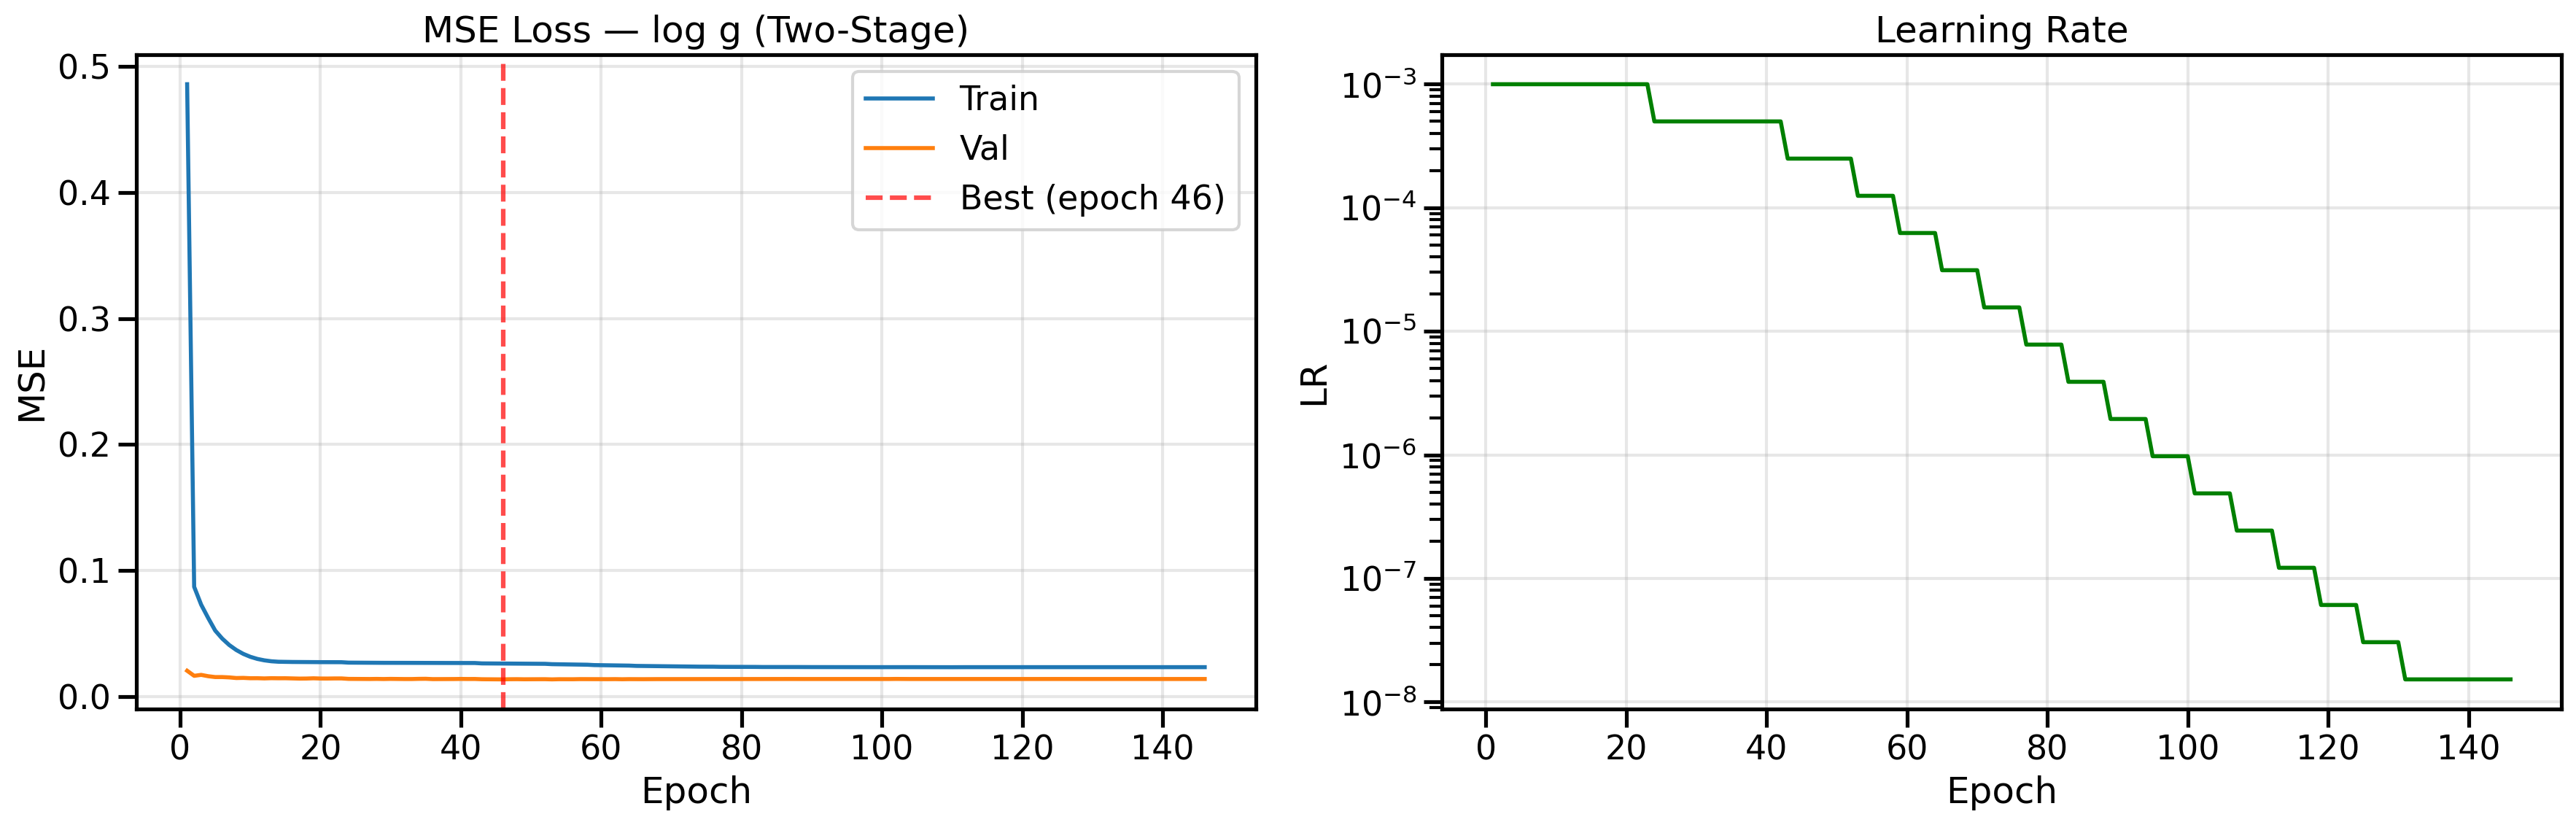

In [12]:
diag = RESULTS_DIR / 'training_diagnostics.png'
if diag.exists():
    ipy_display(IPyImage(filename=str(diag), width=1400))
else:
    print(f'Not found: {diag}')

## 11. Test Set Evaluation

In [13]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        all_preds.append(model(X_b.to(DEVICE)).cpu().numpy())
        all_targets.append(y_b.numpy())

logg_pred = np.concatenate(all_preds)
logg_true = np.concatenate(all_targets)

rmse_logg = np.sqrt(mean_squared_error(logg_true, logg_pred))
mae_logg  = mean_absolute_error(logg_true, logg_pred)
r2_logg   = r2_score(logg_true, logg_pred)

print('=' * 60)
print('  TEST SET — log g Two-Stage ANN')
print('=' * 60)
print(f'  RMSE: {rmse_logg:.4f} dex')
print(f'  MAE:  {mae_logg:.4f} dex')
print(f'  R²:   {r2_logg:.5f}')
print()
for stype in ['F','G','K','M']:
    mask = st_test == stype
    if not mask.any(): continue
    lr2   = r2_score(logg_true[mask], logg_pred[mask])
    lrmse = np.sqrt(mean_squared_error(logg_true[mask], logg_pred[mask]))
    print(f'  {stype}: N={mask.sum():,}  R²={lr2:.4f}  RMSE={lrmse:.4f} dex')

  TEST SET — log g Two-Stage ANN
  RMSE: 0.1177 dex
  MAE:  0.0854 dex
  R²:   0.83249

  F: N=41,225  R²=0.5922  RMSE=0.1062 dex
  G: N=86,818  R²=0.8288  RMSE=0.1234 dex
  K: N=2,834  R²=-0.5204  RMSE=0.1566 dex
  M: N=4,788  R²=0.3672  RMSE=0.0694 dex


## 12. One-to-One Plot

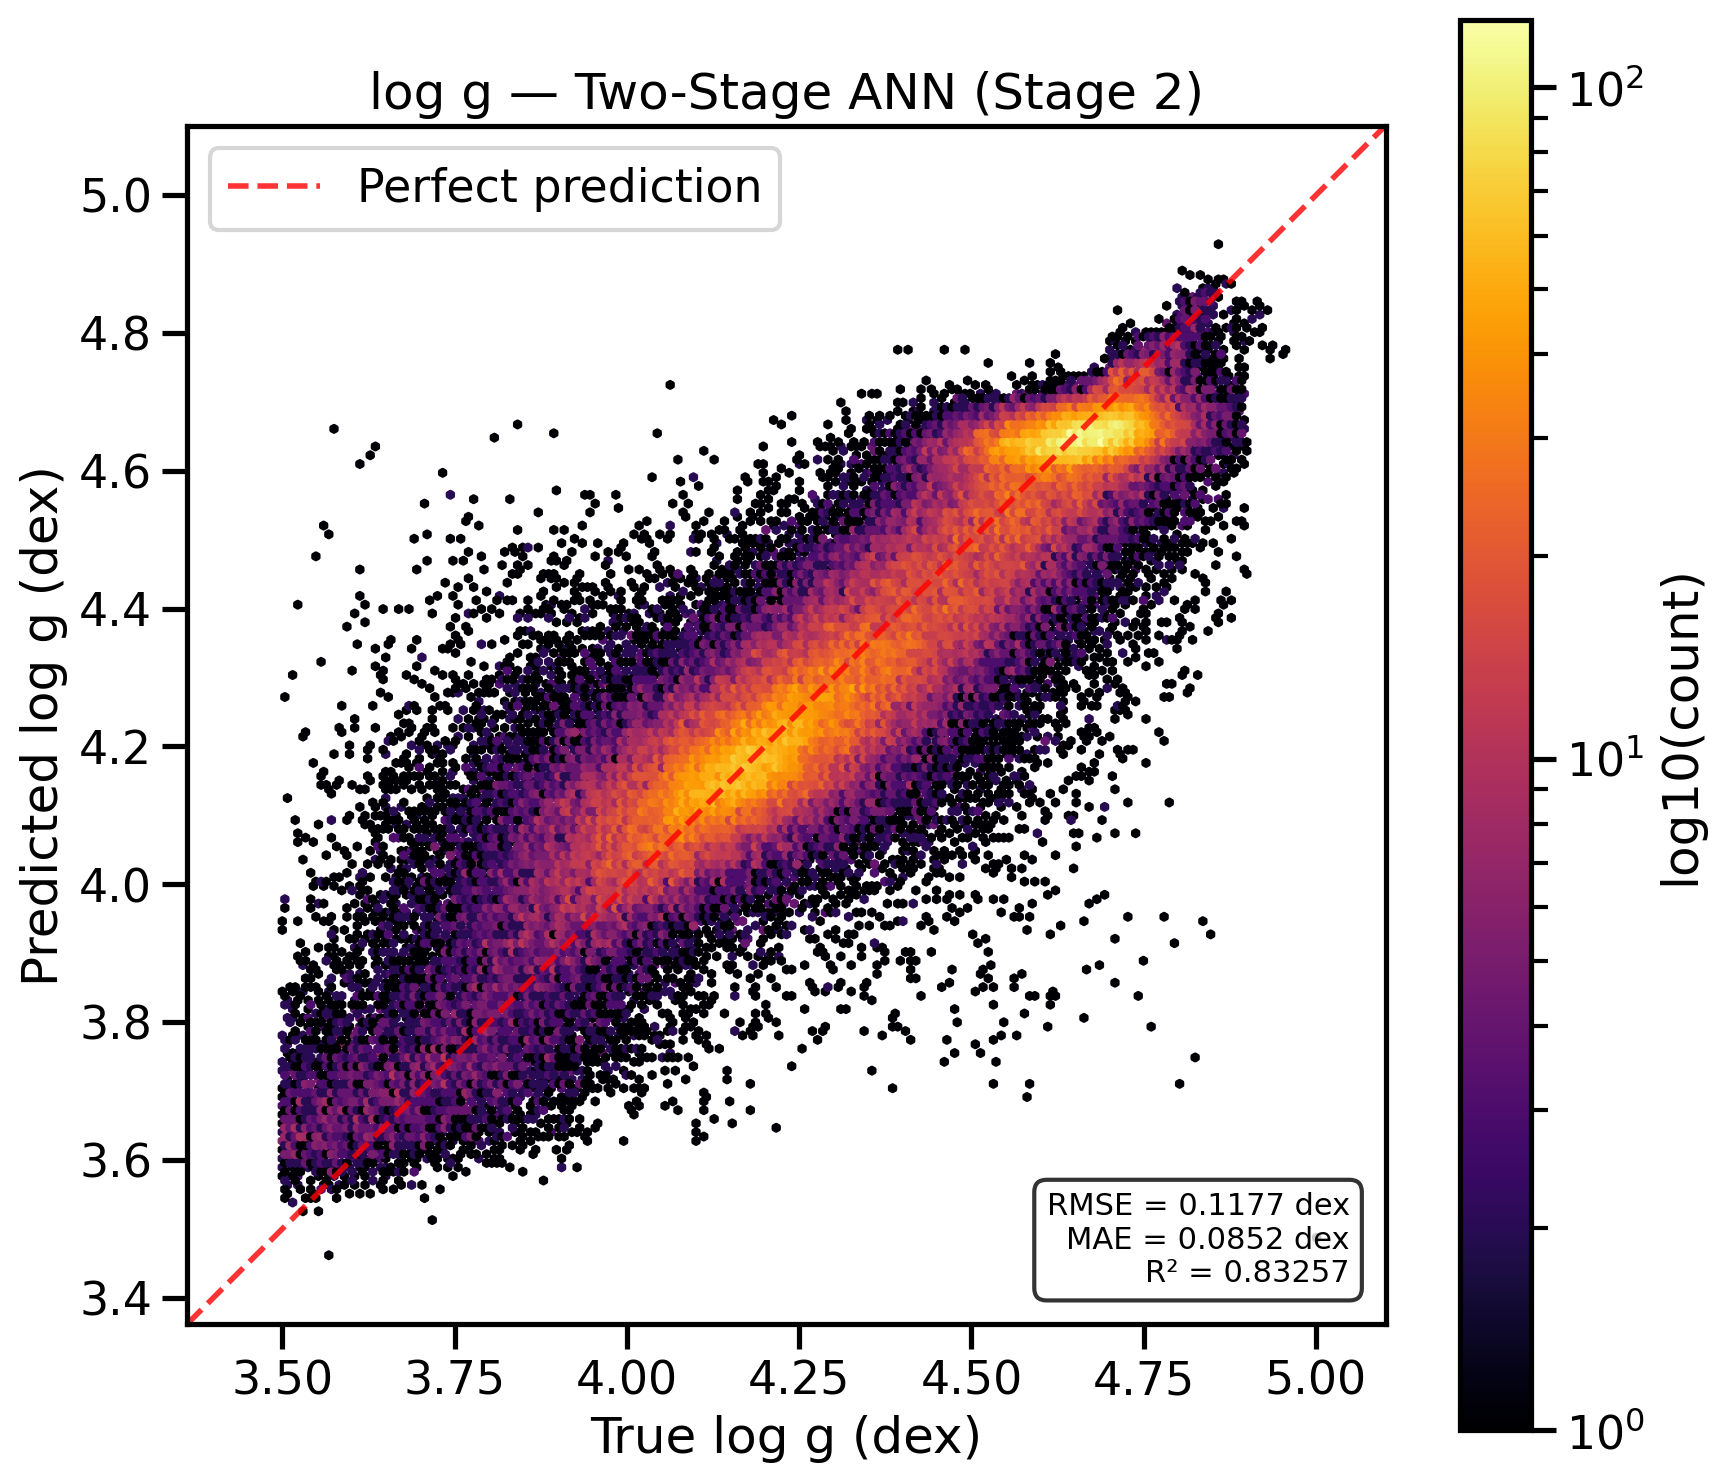

In [14]:
oto = RESULTS_DIR / 'one_to_one_plot.png'
if oto.exists():
    ipy_display(IPyImage(filename=str(oto), width=800))
else:
    fig, ax = plt.subplots(figsize=(9,8))
    hb = ax.hexbin(logg_true, logg_pred, gridsize=200, cmap='inferno', mincnt=1, bins='log')
    plt.colorbar(hb, ax=ax, label='log10(count)')
    lims = [min(logg_true.min(),logg_pred.min())-0.1, max(logg_true.max(),logg_pred.max())+0.1]
    ax.plot(lims, lims, 'r--', lw=2, alpha=0.8)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
    ax.set_xlabel('True log g (dex)'); ax.set_ylabel('Predicted log g (dex)')
    ax.set_title('log g — Two-Stage ANN')
    ax.text(0.97,0.03,f'RMSE={rmse_logg:.4f} dex\nR²={r2_logg:.5f}',
            transform=ax.transAxes, fontsize=11, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8))
    plt.tight_layout(); plt.show()

## 13. Residual Plots

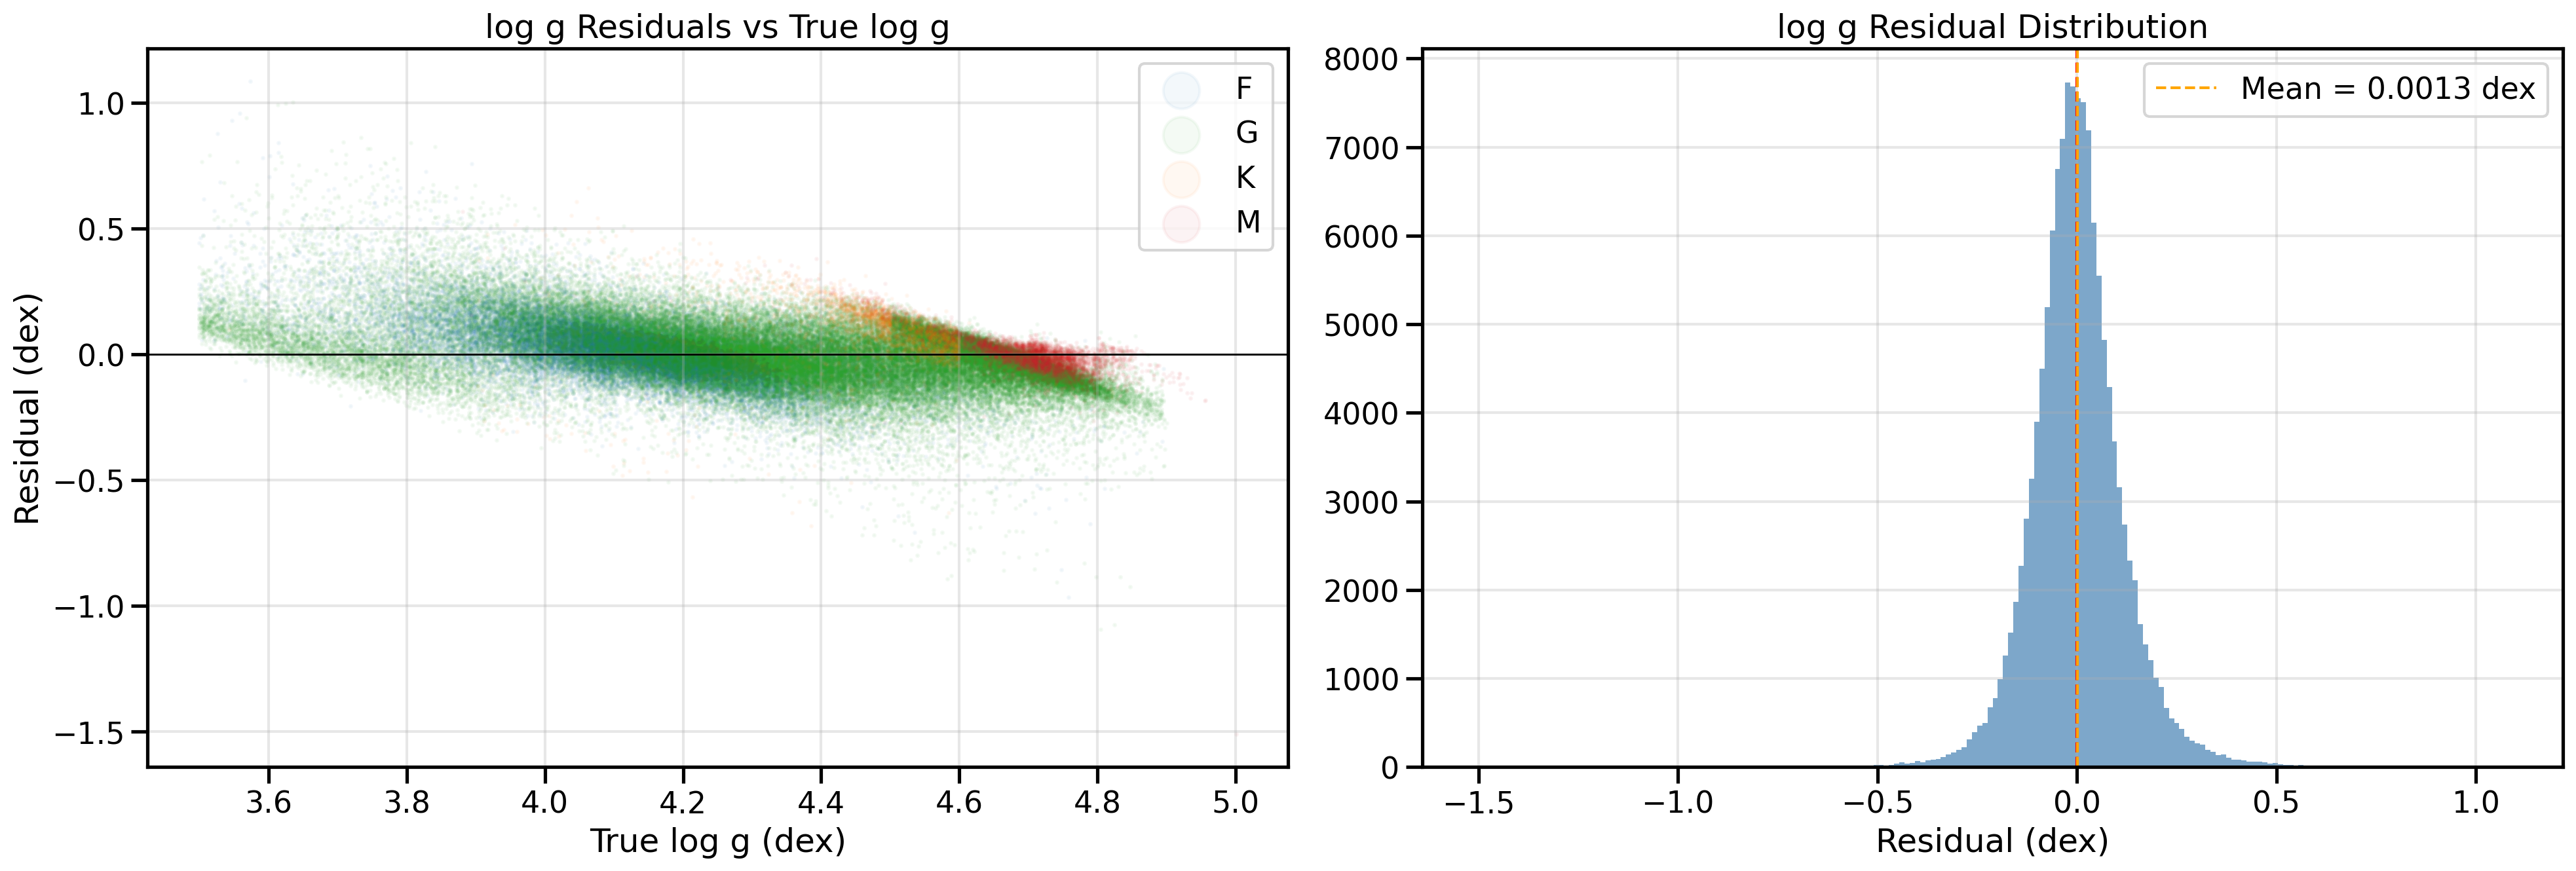

In [15]:
rp = RESULTS_DIR / 'residual_plots.png'
if rp.exists():
    ipy_display(IPyImage(filename=str(rp), width=1400))
else:
    res = logg_pred - logg_true
    colors_map = {'F':'#1f77b4','G':'#2ca02c','K':'#ff7f0e','M':'#d62728'}
    fig, axes = plt.subplots(1,2,figsize=(18,7))
    ax = axes[0]
    for stype in ['F','G','K','M']:
        mask = st_test == stype
        ax.scatter(logg_true[mask], res[mask], alpha=0.05, s=1, color=colors_map[stype], label=stype, rasterized=True)
    ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('True log g (dex)'); ax.set_ylabel('Residual (dex)'); ax.set_title('log g Residuals')
    ax.legend(markerscale=20); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.hist(res, bins=200, alpha=0.7, color='steelblue', edgecolor='none')
    ax.axvline(0, color='red', ls='--', lw=1.5)
    ax.axvline(np.mean(res), color='orange', ls='--', lw=1.5, label=f'Mean={np.mean(res):.4f} dex')
    ax.set_xlabel('Residual (dex)'); ax.set_title('log g Residual Distribution'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 14. Saved Metrics

In [16]:
with open(RESULTS_DIR / 'test_metrics.json') as f:
    metrics = json.load(f)
print(json.dumps(metrics, indent=2))

{
  "model": "logg_twostage_ann",
  "logg": {
    "rmse_dex": 0.117702,
    "mae_dex": 0.085243,
    "r2_score": 0.83257
  },
  "training": {
    "best_epoch": 46,
    "total_epochs_run": 146,
    "n_train_augmented": 2163707,
    "n_val": 135664,
    "n_test": 135665,
    "n_features": 191,
    "stage1_model": "C:\\git_repo\\cool-dwarf_stellar_parameter_inference_from_survey_data\\models\\teff\\stellar_teff_ann_best.pth",
    "stage1_variant": "baseline",
    "augmentation_bin_width_K": 150.0
  },
  "per_type": {
    "F": {
      "logg_r2": 0.591729,
      "logg_rmse": 0.106304
    },
    "G": {
      "logg_r2": 0.829018,
      "logg_rmse": 0.123345
    },
    "K": {
      "logg_r2": -0.526602,
      "logg_rmse": 0.156895
    },
    "M": {
      "logg_r2": 0.368031,
      "logg_rmse": 0.069311
    }
  },
  "baselines": {
    "residual_single_output": {
      "r2": 0.51924,
      "rmse": 0.1994
    },
    "multi_output_homosc": {
      "r2": 0.48343,
      "rmse": 0.20674
    }
  }
}


## 15. Comparison with Baselines

In [17]:
print('=' * 68)
print('  COMPARISON — log g')
print('=' * 68)
print(f'  {"Residual ANN, single-output":<40}  R²=0.51924  RMSE=0.19940 dex')
print(f'  {"Multi-output (homoscedastic)":<40}  R²=0.48343  RMSE=0.20674 dex')
flag = 'IMPROVED' if r2_logg > 0.51924 else 'REGRESSED'
print(f'  {"Two-Stage ANN (this)":<40}  R²={r2_logg:.5f}  RMSE={rmse_logg:.5f} dex'
      f'  ({r2_logg-0.51924:+.5f} R²)  {flag}')

  COMPARISON — log g
  Residual ANN, single-output               R²=0.51924  RMSE=0.19940 dex
  Multi-output (homoscedastic)              R²=0.48343  RMSE=0.20674 dex
  Two-Stage ANN (this)                      R²=0.83249  RMSE=0.11773 dex  (+0.31325 R²)  IMPROVED


## 16. Feature Importance (Permutation)

In [18]:
FEATURE_COLS_191 = FEATURE_COLS_190 + ['pred_log10_teff']

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)
y_test_np     = y_test.flatten()

model.eval()
with torch.no_grad():
    baseline_preds = model(X_test_tensor).cpu().numpy().flatten()
baseline_mse = mean_squared_error(y_test_np, baseline_preds)
print(f'Baseline test MSE: {baseline_mse:.6f}')

importances = []
for i, feat in enumerate(FEATURE_COLS_191):
    X_perm = X_test_tensor.clone()
    X_perm[:, i] = X_perm[torch.randperm(X_perm.size(0)), i]
    with torch.no_grad():
        perm_preds = model(X_perm).cpu().numpy().flatten()
    delta = mean_squared_error(y_test_np, perm_preds) - baseline_mse
    importances.append({'Feature': feat, 'Importance (MSE Increase)': delta})
    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(FEATURE_COLS_191)} done ...')

importance_df = pd.DataFrame(importances).sort_values('Importance (MSE Increase)', ascending=False)
print('\nTop 15 most important features:')
print(importance_df.head(15).to_string(index=False))

Baseline test MSE: 0.013861
  20/191 done ...
  40/191 done ...
  60/191 done ...
  80/191 done ...
  100/191 done ...
  120/191 done ...
  140/191 done ...
  160/191 done ...
  180/191 done ...

Top 15 most important features:
            Feature  Importance (MSE Increase)
COLOR_A_ps_i_A_ps_z                   0.003288
COLOR_A_ps_g_A_ps_r                   0.002903
COLOR_A_ps_i_A_ps_y                   0.002190
COLOR_A_ps_g_A_ps_i                   0.001874
COLOR_A_ps_r_A_ps_i                   0.001318
COLOR_A_ps_r_A_ps_z                   0.001130
COLOR_A_ps_r_A_ps_y                   0.000871
COLOR_A_ps_g_A_ps_z                   0.000727
COLOR_A_ps_z_A_ps_y                   0.000722
COLOR_A_ps_g_A_ps_y                   0.000601
              M_RAP                   0.000559
               M_KS                   0.000513
              M_ISD                   0.000480
             M_ps_i                   0.000456
              M_VAP                   0.000440


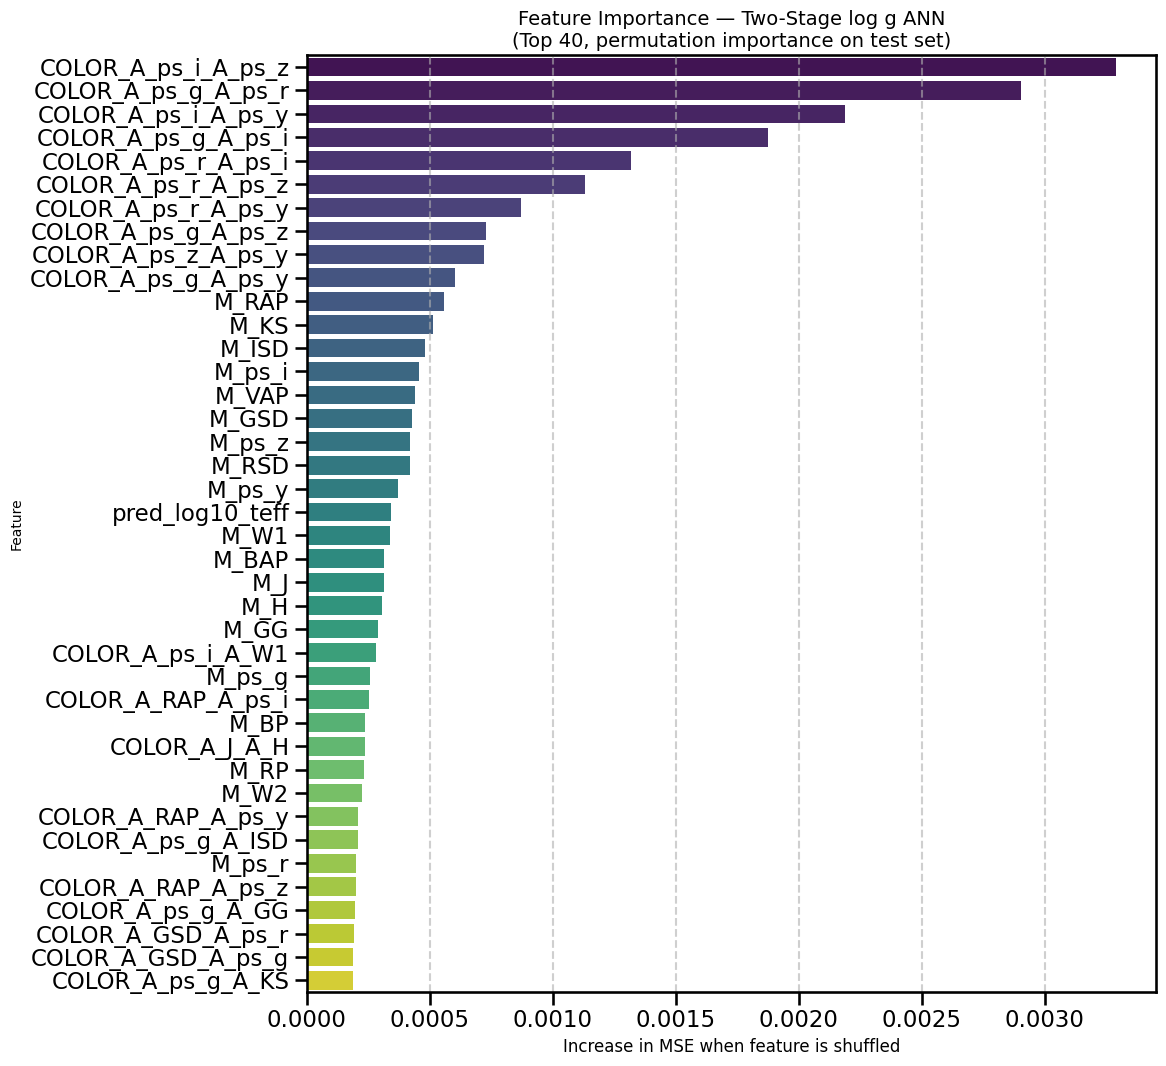

In [19]:
top_n = 40
top_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(12, 11))
sns.barplot(data=top_df, x='Importance (MSE Increase)', y='Feature', palette='viridis', ax=ax)
ax.set_title(f'Feature Importance — Two-Stage log g ANN\n(Top {top_n}, permutation importance on test set)', fontsize=14)
ax.set_xlabel('Increase in MSE when feature is shuffled', fontsize=12)
ax.set_ylabel('Feature', fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()